<a href="https://colab.research.google.com/github/ceyhun2306/data-analysis-python/blob/main/Delivery__Logistics_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.a

chmod: cannot access '/root/.kaggle/kaggle.a': No such file or directory


In [ ]:
#!/bin/bash
!kaggle datasets download ayeshaseherr/delivery-logistics-dataset

Dataset URL: https://www.kaggle.com/datasets/ayeshaseherr/delivery-logistics-dataset
License(s): CC0-1.0
100% 563k/563k [00:00<00:00, 70.5MB/s]



In [ ]:
!unzip/content/delivery-logistics-dataset.zip

/bin/bash: line 1: unzip/content/delivery-logistics-dataset.zip: No such file or directory


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/delivery-logistics-dataset.zip")
df

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24750.01,dhl,furniture,scooter,two day,east,foggy,80.7,3.65,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000016,no,delivered,5,414.4500
24996,24750.01,ecom express,automobile parts,ev van,standard,west,clear,172.9,21.42,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000024,no,delivered,5,928.7600
24997,24750.01,ekart,clothing,scooter,same day,east,rainy,168.4,4.85,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000008,yes,delayed,2,956.5500
24998,24750.01,shadowfax,documents,ev van,standard,west,stormy,37.2,8.04,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000024,no,delivered,5,210.1200


#Dataset Overview
This dataset focuses on delivery and logistics operations, enabling analysis of performance, delay risk, customer satisfaction, and operational costs.
It is particularly useful for HR and Operations teams to understand how human factors, workload characteristics, and external conditions influence outcomes and decision-making.

#Column Descriptions

*  delivery_id
A unique identifier for each delivery record.

* delivery_partner
The partner or team responsible for completing the delivery.

* package_type
The type of package being delivered (e.g., groceries, electronics).

* package_weight_kg
The weight of the package in kilograms, representing physical workload.

* distance_km
The delivery distance, indicating task difficulty and time pressure.

* vehicle_type
The type of vehicle used for delivery (bike, van, truck, etc.).

* delivery_mode
The service level or delivery speed (same day, express, two day).

* region
The geographical area where the delivery takes place.

* weather_condition
The weather conditions during delivery, acting as an external risk factor.

* delivery_time_hours
The actual time taken to complete the delivery (in hours).

* expected_time_hours
The planned or expected delivery time (in hours).

* delayed
Indicates whether the delivery was delayed or on time (yes / no).

* delivery_status
The final status of the delivery (e.g., delivered).

* delivery_rating
The customer satisfaction score, reflecting service quality.

* delivery_cost
The total operational cost incurred for the delivery.

In [ ]:
df.shape

(25000, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          25000 non-null  float64
 1   delivery_partner     25000 non-null  object 
 2   package_type         25000 non-null  object 
 3   vehicle_type         25000 non-null  object 
 4   delivery_mode        25000 non-null  object 
 5   region               25000 non-null  object 
 6   weather_condition    25000 non-null  object 
 7   distance_km          25000 non-null  float64
 8   package_weight_kg    25000 non-null  float64
 9   delivery_time_hours  25000 non-null  object 
 10  expected_time_hours  25000 non-null  object 
 11  delayed              25000 non-null  object 
 12  delivery_status      25000 non-null  object 
 13  delivery_rating      25000 non-null  int64  
 14  delivery_cost        25000 non-null  float64
dtypes: float64(4), int64(1), object(10)


The dataset consists of a total of 25,000 rows and 14 columns.
All columns have correct data types, and there are no missing values.
Overall, the dataset contains 4 float-type columns, 1 integer-type column, and 10 string-type columns.

In [ ]:
df.describe()

,delivery_id,distance_km,package_weight_kg,delivery_rating,delivery_cost
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,3.666000,864.944579
std,7212.732314,86.409745,14.368663,1.149964,435.712593
min,250.990000,3.600000,0.670000,1.000000,95.667400
25%,6250.750000,75.900000,12.680000,3.000000,490.800000
50%,12500.500000,151.000000,25.145000,4.000000,867.535000
75%,18750.250000,224.900000,37.660000,5.000000,1237.910000
max,24750.010000,297.100000,49.520000,5.000000,1632.720600


In [ ]:
df.isna().sum()

,0
delivery_id,0
delivery_partner,0
package_type,0
vehicle_type,0
delivery_mode,0
region,0
weather_condition,0
distance_km,0
package_weight_kg,0
delivery_time_hours,0


From here we can also see that there is no any missing data

In [ ]:
df.head(10)

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600
5,250.99,amazon logistics,documents,ev bike,express,west,rainy,48.4,33.15,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000002,yes,delayed,3,391.4500
6,250.99,delhivery,groceries,scooter,same day,central,clear,198.3,43.79,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1222.8700
7,250.99,xpressbees,fragile items,van,same day,north,cold,114.6,42.63,1970-01-01 00:00:00.000000004,1970-01-01 00:00:00.000000008,no,delivered,3,800.8900
8,250.99,blue dart,clothing,van,same day,south,hot,142.4,14.06,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000008,no,delivered,5,854.1800
9,250.99,delhivery,pharmacy,truck,same day,east,foggy,47.1,29.28,1970-01-01 00:00:00.000000003,1970-01-01 00:00:00.000000008,no,delivered,5,423.3400


In [ ]:
df.drop(columns=["delivery_time_hours", "expected_time_hours"], inplace=True)
df.head(10)

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,no,delivered,4,1394.5600
5,250.99,amazon logistics,documents,ev bike,express,west,rainy,48.4,33.15,yes,delayed,3,391.4500
6,250.99,delhivery,groceries,scooter,same day,central,clear,198.3,43.79,no,delivered,3,1222.8700
7,250.99,xpressbees,fragile items,van,same day,north,cold,114.6,42.63,no,delivered,3,800.8900
8,250.99,blue dart,clothing,van,same day,south,hot,142.4,14.06,no,delivered,5,854.1800
9,250.99,delhivery,pharmacy,truck,same day,east,foggy,47.1,29.28,no,delivered,5,423.3400


#Distribution of Deliveries Across Delivery Partners

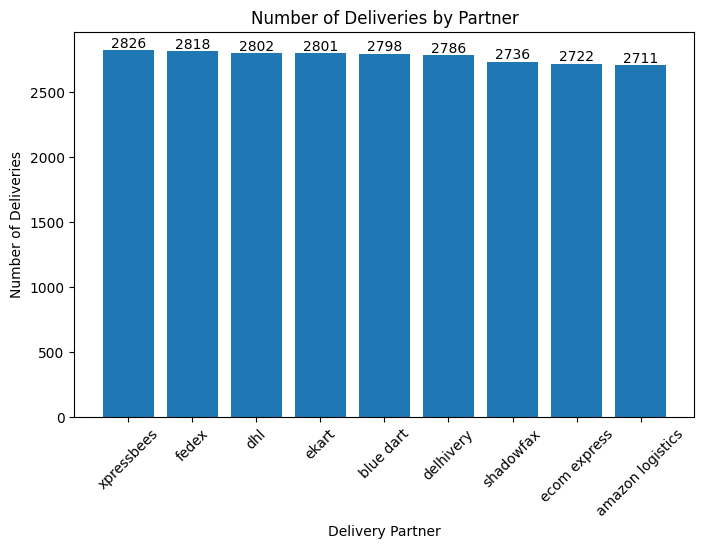

In [ ]:
counts = df['delivery_partner'].value_counts()

plt.figure(figsize=(8,5))
bars = plt.bar(counts.index, counts.values)

plt.bar_label(bars)

plt.xlabel("Delivery Partner")
plt.ylabel("Number of Deliveries")
plt.title("Number of Deliveries by Partner")
plt.xticks(rotation = 45)
plt.show()

The visualization shows that delivery volumes are fairly evenly distributed across partners. However, XpressBees, FedEx, DHL, and Ekart stand out as the most active partners, each handling over 2,800 deliveries.

In contrast, Amazon Logistics and Ecom Express appear at the lower end of the distribution, with very similar delivery counts.

Overall, the close distribution suggests that partner usage is not driven by a single dominant factor. Differences may instead be influenced by service quality, on-time performance, or customer ratings, which can affect partner selection over time.

#Average Delivery Rating and Cost by Partner

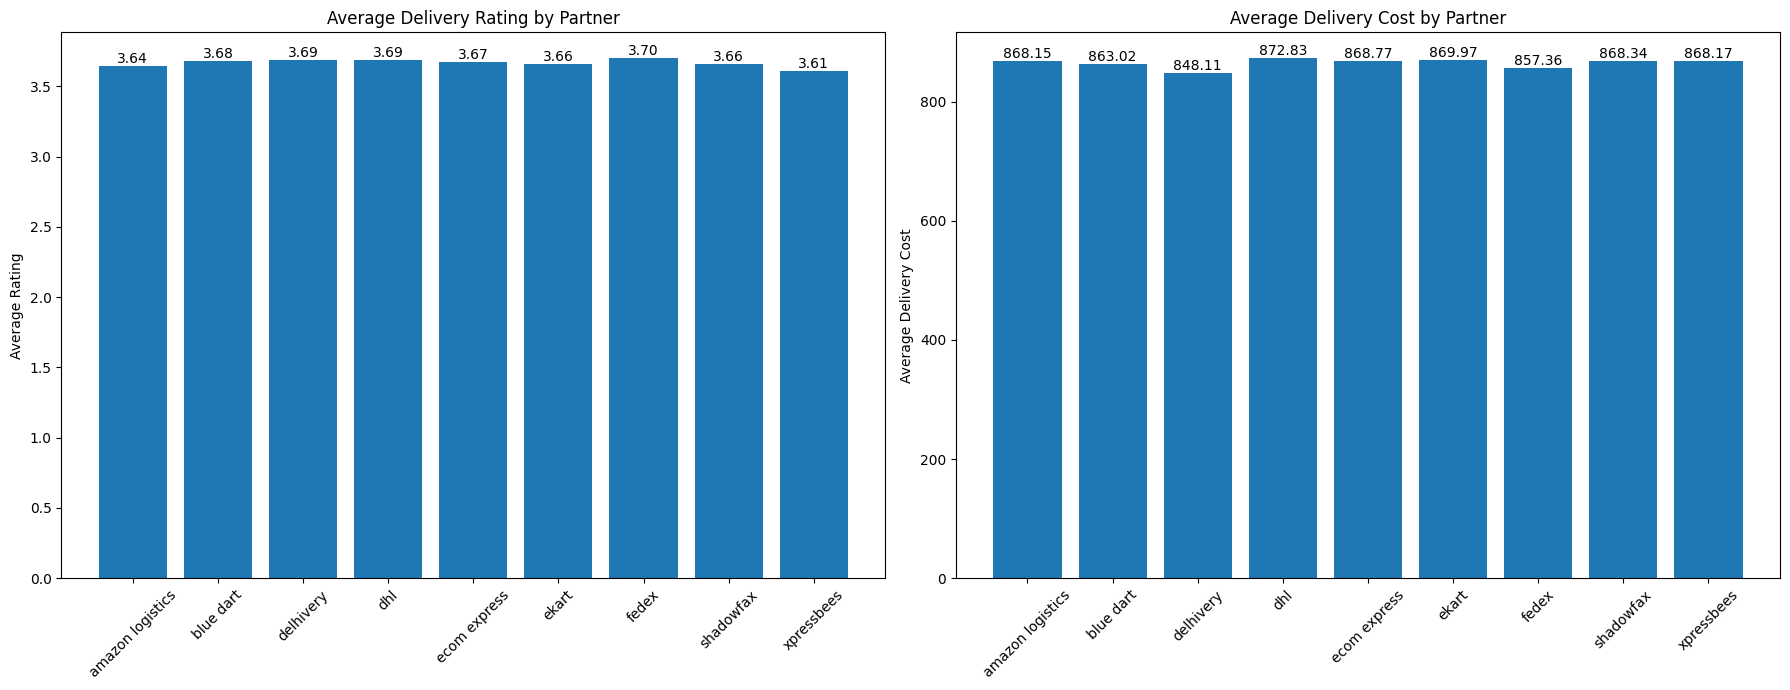

In [ ]:
avg_rating = df.groupby('delivery_partner')['delivery_rating'].mean()
avg_cost = df.groupby('delivery_partner')['delivery_cost'].mean()

fig, axes = plt.subplots(1, 2, figsize=(18,7))

bars1 = axes[0].bar(avg_rating.index, avg_rating.values)
axes[0].bar_label(bars1, fmt='%.2f')
axes[0].set_ylabel("Average Rating")
axes[0].set_title("Average Delivery Rating by Partner")
axes[0].tick_params(axis='x', rotation=45)

bars2 = axes[1].bar(avg_cost.index, avg_cost.values)
axes[1].bar_label(bars2, fmt='%.2f')
axes[1].set_ylabel("Average Delivery Cost")
axes[1].set_title("Average Delivery Cost by Partner")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In the left visualization, average delivery ratings across partners fall within a narrow range (3.60–3.70), indicating generally consistent service quality. However, XpressBees, despite having the highest delivery volume, shows a slightly lower average rating, likely due to scale effects where higher volume increases the chance of negative feedback.

FedEx and DHL stand out with slightly higher ratings, suggesting stronger customer satisfaction despite handling a large number of deliveries. In contrast, Amazon Logistics combines a lower delivery volume with one of the lowest average ratings, which helps explain its limited usage.

In the right visualization, DHL has a higher average delivery cost but remains widely used, highlighting that service quality can justify higher pricing. Meanwhile, Amazon Logistics shows relatively high costs without strong ratings, indicating that price reduction would likely be the most effective way to increase its usage.

#On-Time vs Delayed Deliveries by Partner

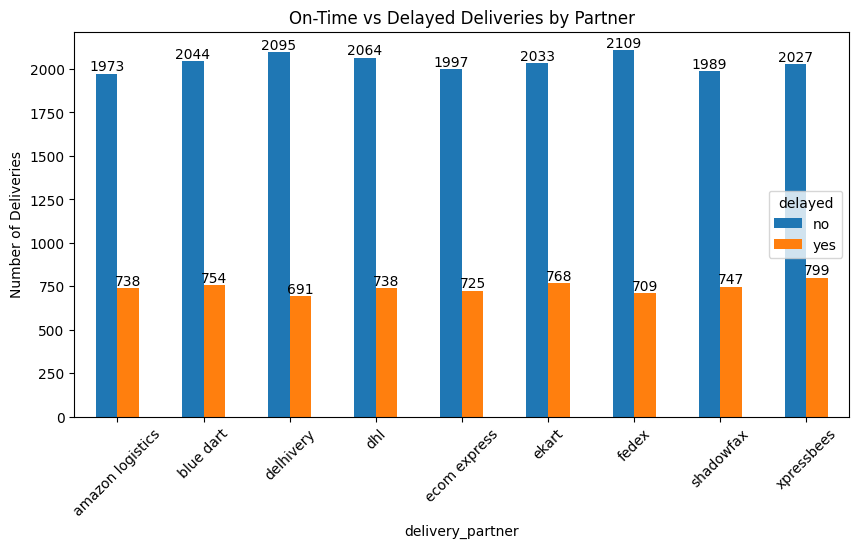

In [ ]:
delayed_counts = df.groupby(['delivery_partner', 'delayed']).size().unstack(fill_value=0)
delayed_counts = delayed_counts.rename(columns={0: 'On-Time', 1: 'Delayed'})

ax = delayed_counts.plot(kind='bar', figsize=(10,5))
plt.ylabel("Number of Deliveries")
plt.title("On-Time vs Delayed Deliveries by Partner")
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

The visualization shows clear differences in on-time performance across delivery partners. XpressBees records the highest number of delayed deliveries, which directly contributes to its lower average rating. Similarly, Ekart also shows a high delay count and relatively weaker ratings.

In contrast, Delhivery and FedEx have the fewest delayed deliveries, which helps explain their higher customer ratings. Overall, this visualization highlights that delivery delays are a key driver of rating differences across partners.

#Distribution of Deliveries Across Delivery Partners

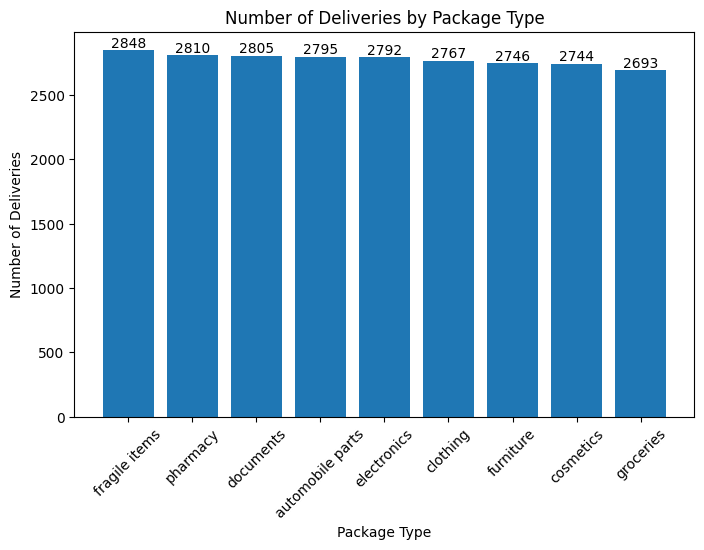

In [ ]:
package_counts = df['package_type'].value_counts()

plt.figure(figsize=(8,5))
bars = plt.bar(package_counts.index, package_counts.values)
plt.bar_label(bars)
plt.xlabel("Package Type")
plt.ylabel("Number of Deliveries")
plt.title("Number of Deliveries by Package Type")
plt.xticks(rotation = 45)
plt.show()

The visualization shows clear differences in delivery counts by package type. Fragile Items lead with 2,848 deliveries, followed by Pharmacy and Documents, which are generally easier and lower-risk to deliver.

In contrast, Groceries and Cosmetics have noticeably lower delivery counts, likely because long-distance delivery is less practical for these items. These differences suggest that delivery feasibility and demand strongly influence package-type distribution.

#Average Rating and Delivery Cost by Package Type

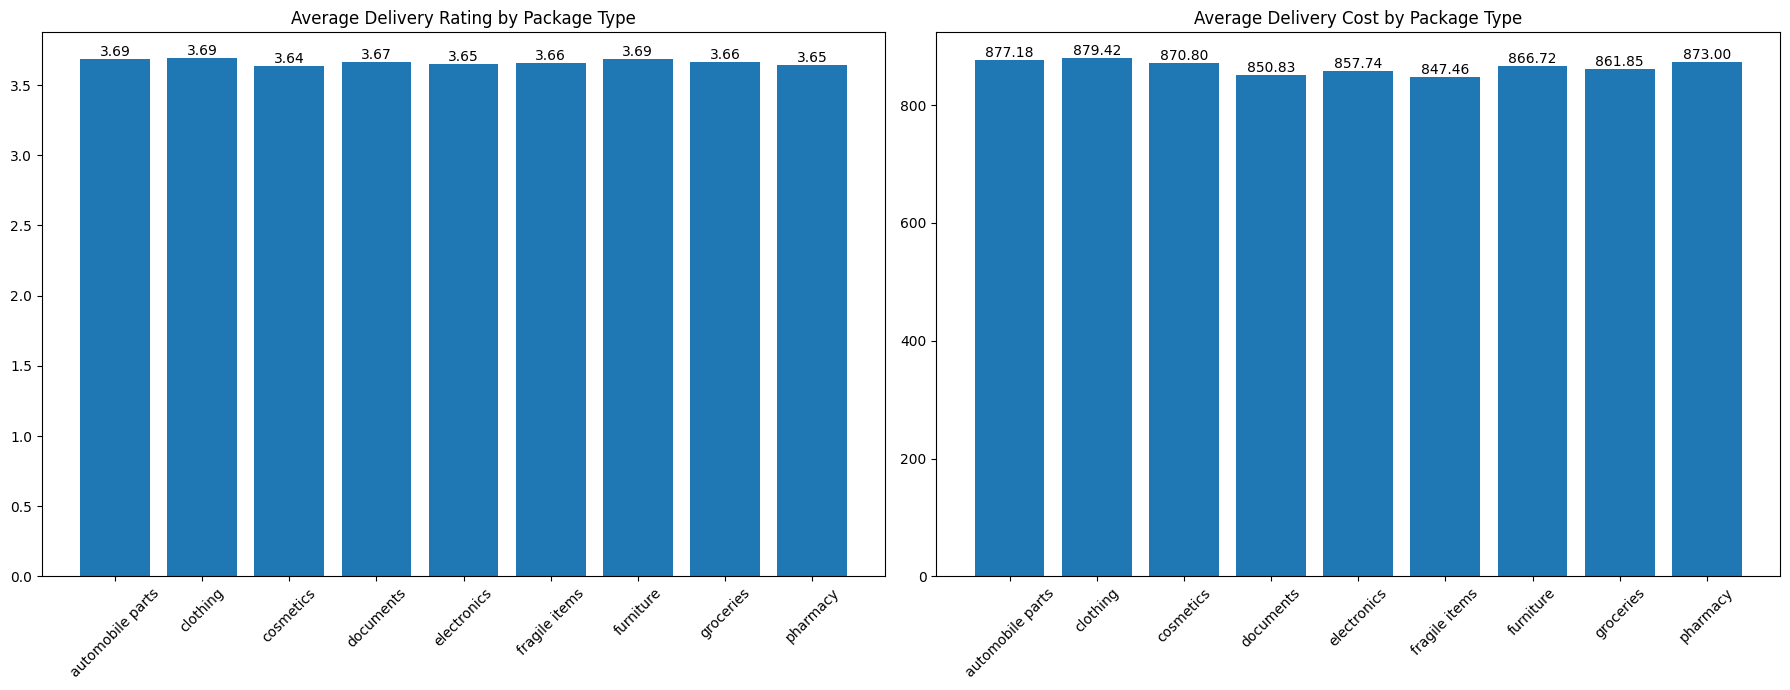

In [ ]:
avg_rating_pkg = df.groupby('package_type')['delivery_rating'].mean()
avg_cost_pkg = df.groupby('package_type')['delivery_cost'].mean()

fig, axes = plt.subplots(1, 2, figsize=(18,7))

bars1 = axes[0].bar(avg_rating_pkg.index, avg_rating_pkg.values)
axes[0].bar_label(bars1, fmt='%.2f')
axes[0].set_title("Average Delivery Rating by Package Type")
axes[0].tick_params(axis='x', rotation=45)

bars2 = axes[1].bar(avg_cost_pkg.index, avg_cost_pkg.values)
axes[1].bar_label(bars2, fmt='%.2f')
axes[1].set_title("Average Delivery Cost by Package Type")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The visualizations show clear differences in average rating and delivery cost across package types. Automobile Parts, Clothing, and Furniture have higher ratings, likely due to fewer delivery delays. In contrast, Cosmetics has a significantly lower rating, which helps explain its lower order volume.

In terms of cost, Clothing has the highest delivery cost, followed by Automobile Parts, yet demand remains stable. Meanwhile, Fragile Items are the lowest-cost category while having very high delivery volume, suggesting there is room for a slight price increase without negatively affecting demand.

#Vehicle Type Utilization: Number of Deliveries

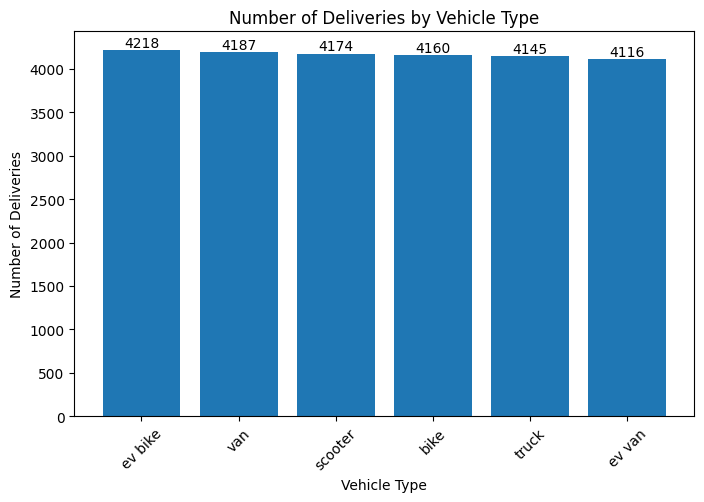

In [ ]:
vehicle_counts = df['vehicle_type'].value_counts()

plt.figure(figsize=(8,5))
bars = plt.bar(vehicle_counts.index, vehicle_counts.values)
plt.bar_label(bars)
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Deliveries")
plt.title("Number of Deliveries by Vehicle Type")
plt.xticks(rotation=45)
plt.show()

The visualization highlights clear differences in vehicle usage. EV Bikes are the most frequently used, handling 4,218 deliveries, followed closely by Vans with 4,187 deliveries.

In contrast, EV Vans are the least utilized, suggesting that traditional vans are currently more operationally efficient and better aligned with delivery requirements. Overall, this pattern indicates a preference for practical and demand-ready vehicle types, which we will explore further in the next analysis.

#Vehicle Type Performance Analysis: Average Distance and Rating

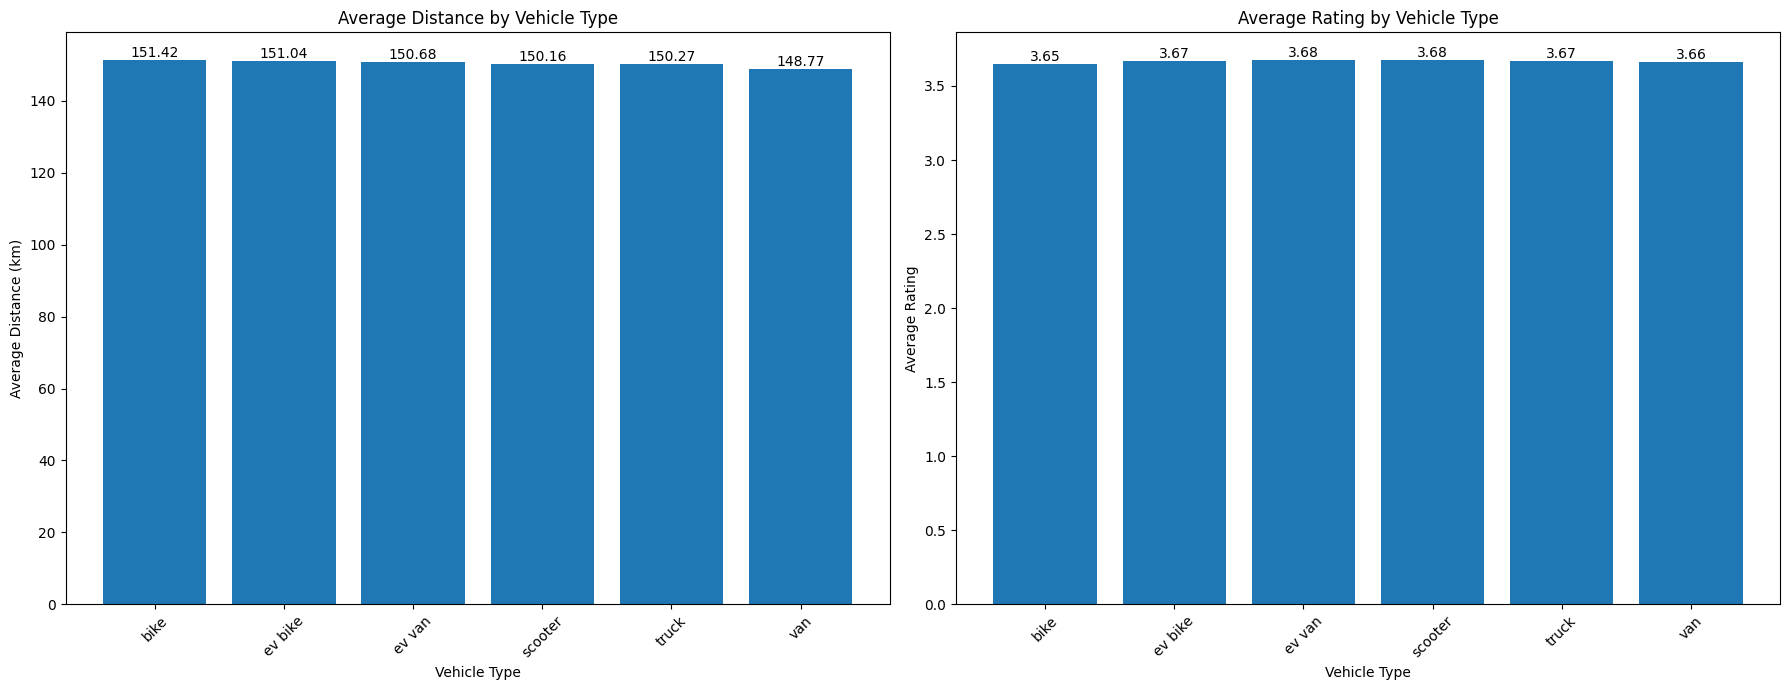

In [ ]:
vehicle_distance_mean = df.groupby('vehicle_type')['distance_km'].mean()
vehicle_rating_mean = df.groupby('vehicle_type')['delivery_rating'].mean()

fig, axes = plt.subplots(1, 2, figsize=(18,7))

bars1 = axes[0].bar(vehicle_distance_mean.index, vehicle_distance_mean.values)
axes[0].bar_label(bars1, fmt='%.2f')
axes[0].set_xlabel("Vehicle Type")
axes[0].set_ylabel("Average Distance (km)")
axes[0].set_title("Average Distance by Vehicle Type")
axes[0].tick_params(axis='x', rotation=45)

bars2 = axes[1].bar(vehicle_rating_mean.index, vehicle_rating_mean.values)
axes[1].bar_label(bars2, fmt='%.2f')
axes[1].set_xlabel("Vehicle Type")
axes[1].set_ylabel("Average Rating")
axes[1].set_title("Average Rating by Vehicle Type")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The left visualization shows that Bikes cover the highest average distance, followed by EV Bikes, which are also the most frequently used vehicle type. In contrast, Vans operate over the shortest average distances, despite their high usage.

On the right, average ratings across vehicle types are very similar. However, EV Vans stand out with a higher average rating, suggesting a more premium service positioning. Meanwhile, Bikes have the lowest average rating, likely due to high usage volume increasing customer feedback variability.

#Average Delivery Cost by Vehicle Type

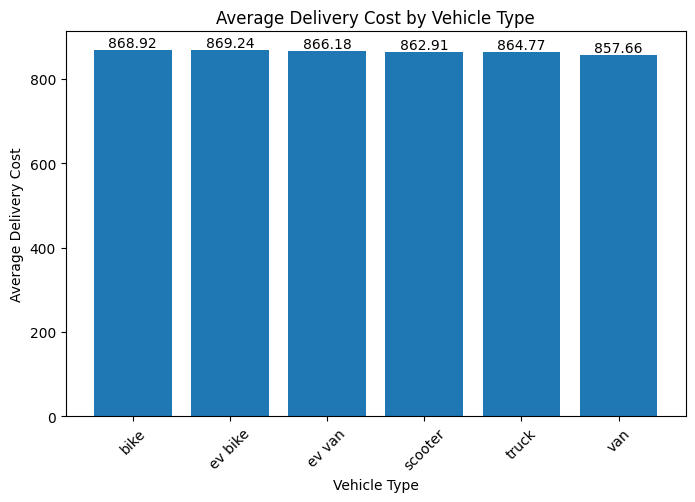

In [ ]:
vehicle_cost_mean = df.groupby('vehicle_type')['delivery_cost'].mean()

plt.figure(figsize=(8,5))
bars = plt.bar(vehicle_cost_mean.index, vehicle_cost_mean.values)
plt.bar_label(bars, fmt='%.2f')
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Cost")
plt.title("Average Delivery Cost by Vehicle Type")
plt.xticks(rotation=45)
plt.show()

The visualization highlights clear differences in delivery costs by vehicle type. Vans are the most affordable, which helps explain their high usage, while EV Vans are more expensive, limiting their adoption despite acceptable performance ratings. A price reduction could improve EV Van usage.

Both EV Bikes and Bikes have relatively high costs. However, EV Bikes maintain dominant usage and strong ratings, suggesting that demand would remain stable even with a slight price increase.

In contrast, Bikes combine lower ratings with weaker demand, indicating that a moderate price reduction could be an effective strategy to boost usage.

#Delivery Mode and Region Distribution

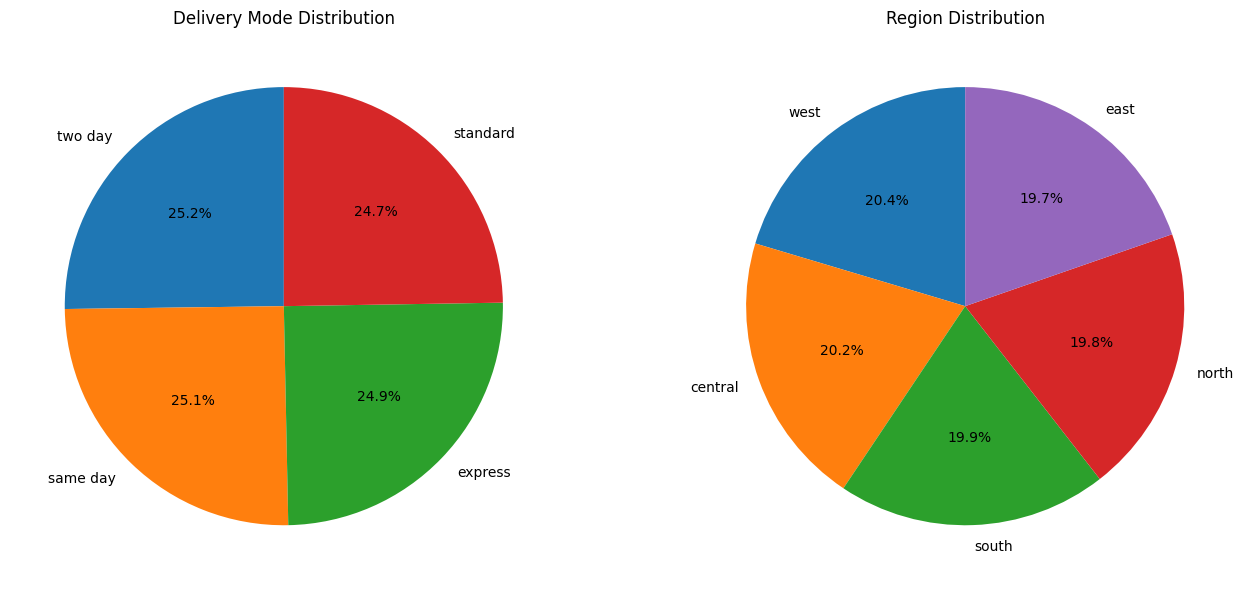

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

delivery_mode_counts = df['delivery_mode'].value_counts()
axes[0].pie(delivery_mode_counts, labels=delivery_mode_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title("Delivery Mode Distribution")

region_counts = df['region'].value_counts()
axes[1].pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Region Distribution")

plt.tight_layout()
plt.show()

This visualization shows the percentage distribution of delivery modes and the regions to which deliveries were made. Looking at the delivery modes, the most frequently used mode is Two Day, followed closely by Same Day with a slightly lower percentage, and Express comes next. The least used mode is Standard, accounting for only 24.7% of deliveries.

#Correlation between Average Distance and Delivery Cost by Region

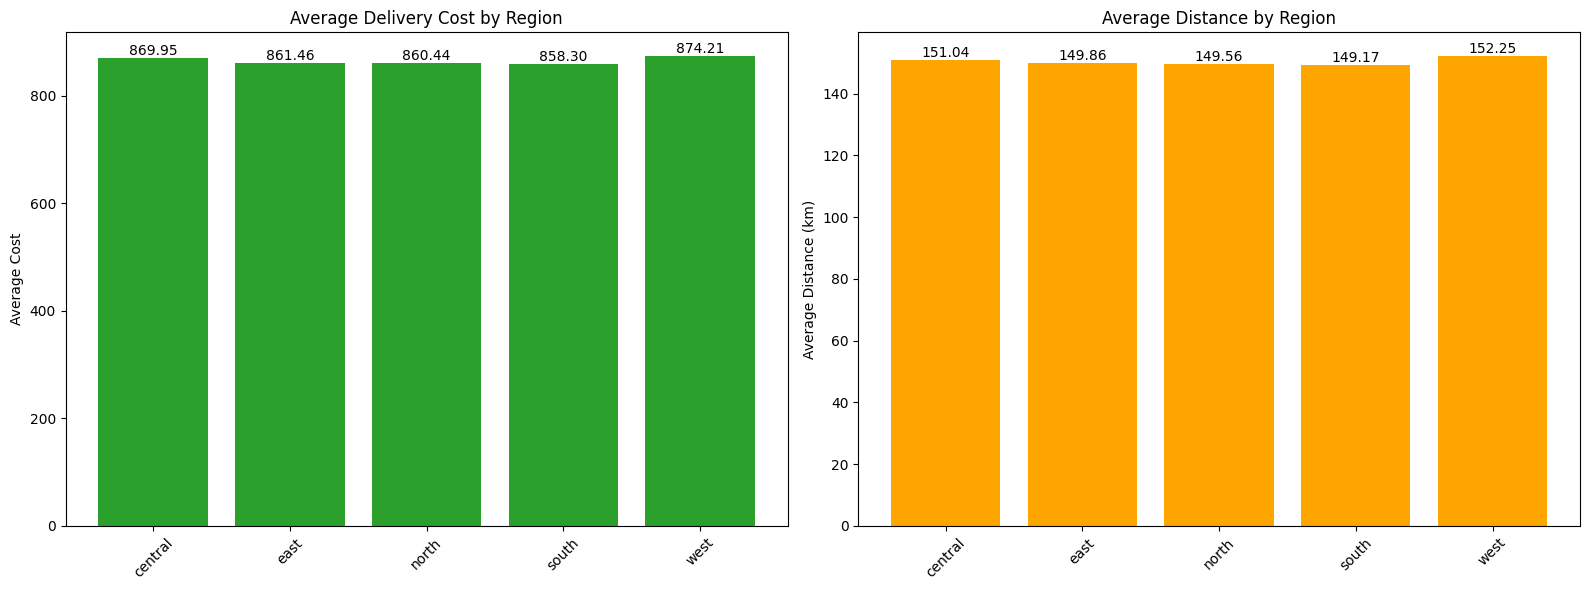

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

region_cost = df.groupby('region')['delivery_cost'].mean()
axes[0].bar(region_cost.index, region_cost.values, color='#2ca02c')  # Yaşıl ton
axes[0].bar_label(axes[0].containers[0], fmt='%.2f')
axes[0].set_title("Average Delivery Cost by Region")
axes[0].set_ylabel("Average Cost")
axes[0].tick_params(axis='x', rotation=45)

region_distance = df.groupby('region')['distance_km'].mean()
axes[1].bar(region_distance.index, region_distance.values, color='orange')
axes[1].bar_label(axes[1].containers[0], fmt='%.2f')
axes[1].set_title("Average Distance by Region")
axes[1].set_ylabel("Average Distance (km)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Examining these visualizations, we can observe a clear correlation between regions: deliveries covering longer distances tend to incur higher costs. Specifically, West and Central regions are located farther away, which is reflected in their comparatively higher average delivery fees. Conversely, regions with shorter average distances naturally have lower delivery costs, demonstrating a consistent relationship between distance traveled and pricing.

#Deliveries and Average Delivery Cost by Weather Condition

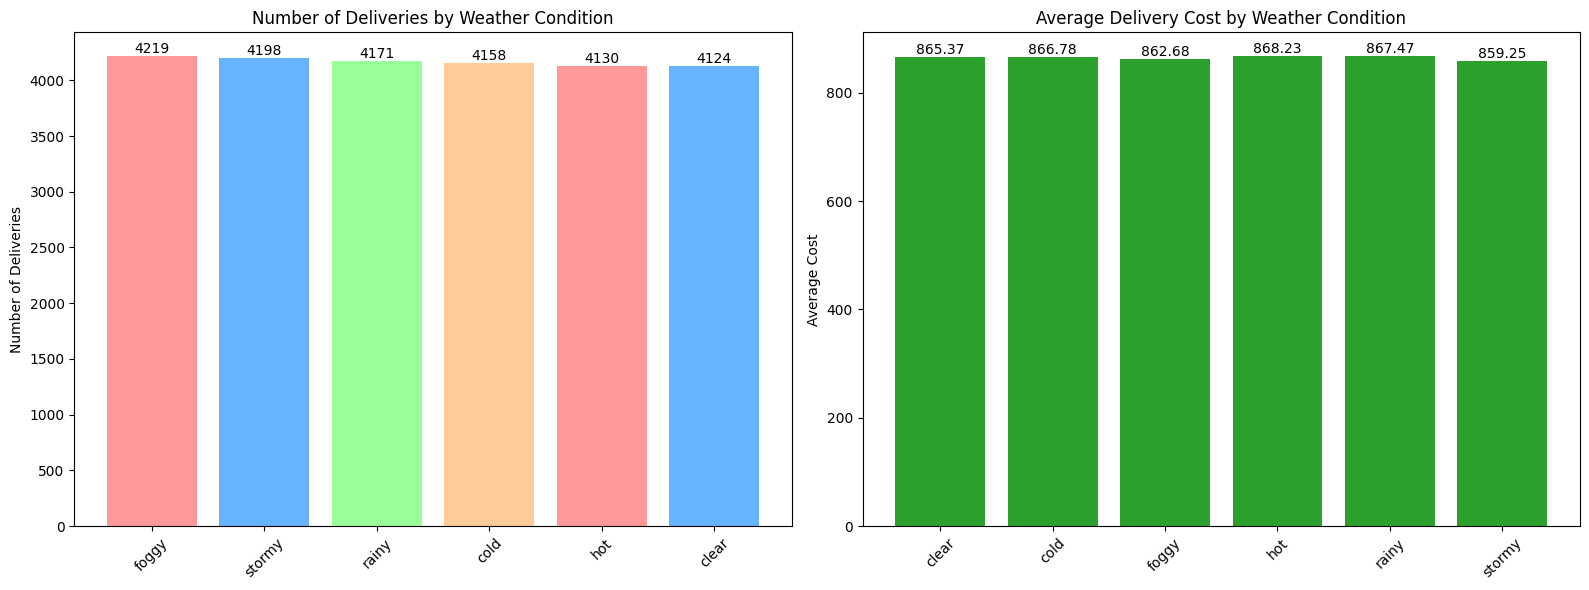

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

weather_counts = df['weather_condition'].value_counts()
colors_counts = ['#ff9999','#66b3ff','#99ff99','#ffcc99']  # fərqli rənglər
axes[0].bar(weather_counts.index, weather_counts.values, color=colors_counts)
axes[0].bar_label(axes[0].containers[0])
axes[0].set_title("Number of Deliveries by Weather Condition")
axes[0].set_ylabel("Number of Deliveries")
axes[0].tick_params(axis='x', rotation=45)

weather_cost_mean = df.groupby('weather_condition')['delivery_cost'].mean()
axes[1].bar(weather_cost_mean.index, weather_cost_mean.values, color='#2ca02c')  # eyni yaşıl rəng
axes[1].bar_label(axes[1].containers[0], fmt='%.2f')
axes[1].set_title("Average Delivery Cost by Weather Condition")
axes[1].set_ylabel("Average Cost")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The left chart illustrates the number of deliveries by weather condition, while the right chart shows the average delivery cost for each weather condition.

From the left chart, we can see that deliveries are fairly evenly distributed across weather conditions, with foggy and stormy days having slightly higher counts, but overall the differences are minimal.

The right chart shows that average delivery costs are also relatively consistent across weather conditions, ranging roughly between 859 and 868. This indicates that weather has a limited impact on the pricing, even though minor variations exist, such as slightly higher costs during hot or stormy conditions.

Overall, the charts suggest that both delivery volume and cost are relatively stable regardless of weather.

#Delivery Status Distribution

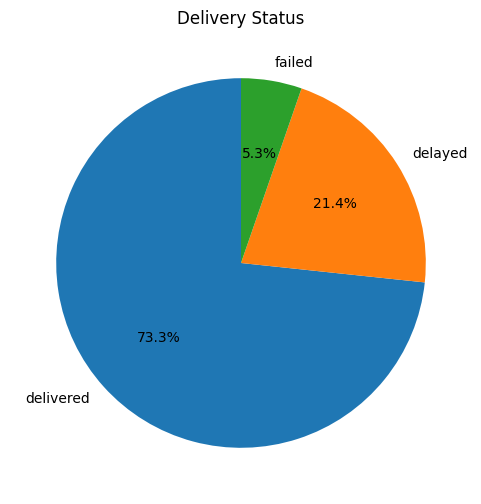

In [ ]:
status_counts = df['delivery_status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Delivery Status')
plt.show()

According to the delivery status pie chart, 73.3% of the orders were successfully delivered on time, 5.3% of the deliveries failed, and 21.4% were delayed. This indicates that while the majority of deliveries are completed successfully, there is still a significant portion that experiences delays, which could impact customer satisfaction and operational efficiency. Addressing the causes of delays could help improve overall delivery performance.

#Average Delivery Rating Distribution by Delivery Status

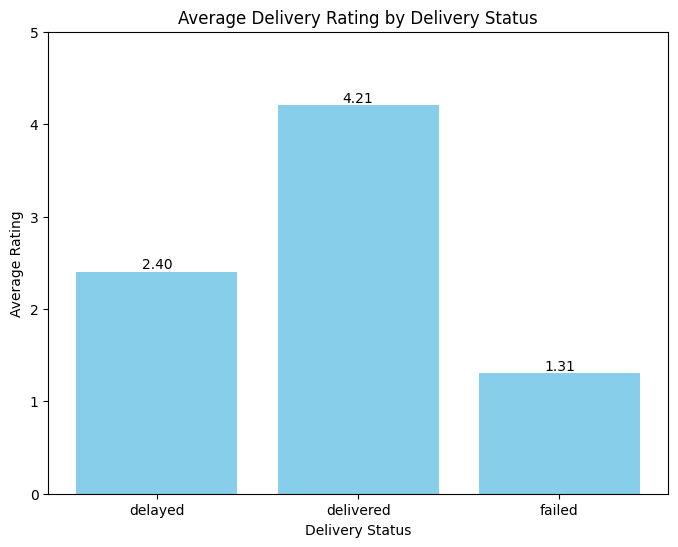

In [ ]:
avg_rating = df.groupby('delivery_status')['delivery_rating'].mean()

plt.figure(figsize=(8,6))
bars = plt.bar(avg_rating.index, avg_rating.values, color='skyblue')

plt.bar_label(bars, fmt='%.2f')

plt.title('Average Delivery Rating by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.show()

Analyzing the average delivery ratings by status, we see that delayed deliveries have an average rating of 2.4, successfully delivered orders have a much higher average rating of 4.21, and failed deliveries receive the lowest average rating of 1.31. This clearly indicates that timely and successful deliveries strongly influence customer satisfaction, while delays and failures significantly reduce it.

#Average Delivery Rating Distribution

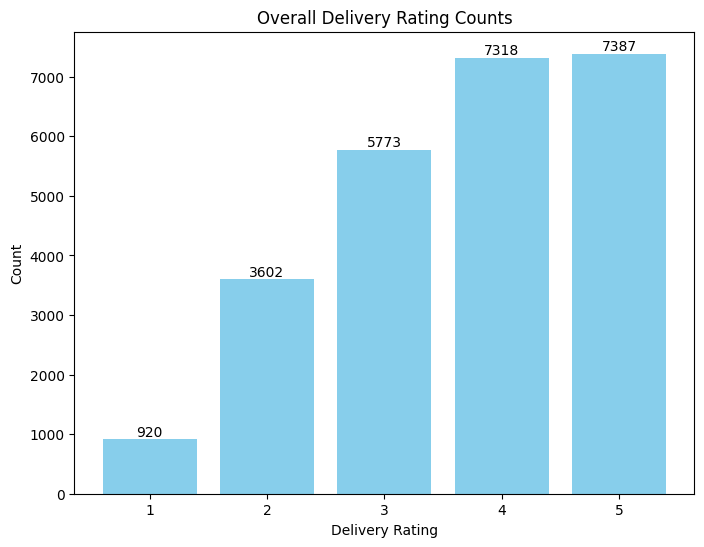

In [ ]:
rating_counts = df['delivery_rating'].value_counts().sort_index()

plt.figure(figsize=(8,6))
bars = plt.bar(rating_counts.index.astype(str), rating_counts.values, color='skyblue')

plt.bar_label(bars)

plt.title('Overall Delivery Rating Counts')
plt.xlabel('Delivery Rating')
plt.ylabel('Count')
plt.show()

Overall, the company's delivery ratings are good. The majority of ratings are 4 and 5, which indicates a positive performance. Although the number of deliveries with a rating of 1 is very low, there are relatively more deliveries rated 2 and 3. If the company reduces the number of delayed or failed deliveries, an improvement in the overall ratings can be expected.

#Summary about analyse of this dataset

After analyzing the company's delivery data, several key insights emerge about performance, customer satisfaction, and operational efficiency:

* Delivery Partners: XpressBees, FedEx, DHL, and Ekart handle the largest share of deliveries, while Amazon Logistics and Ecom Express operate at the lower end of the scale. Despite close delivery counts among partners, differences in service quality, punctuality, and customer ratings influence how frequently each partner is used.

* Customer Ratings: Overall, delivery ratings are strong, with most orders receiving 4 or 5 stars. On average, successfully delivered orders score 4.21, delayed deliveries drop to 2.4, and failed deliveries fall to 1.31. Timely and reliable service clearly drives customer satisfaction.

* Delivery Costs: While costs vary across partners and package types, DHL stands out for higher pricing yet maintains high usage, reflecting its perceived service quality. Lower-cost options like Van deliveries show strong adoption, suggesting a balance between cost and operational efficiency.

* Package Types: Fragile Items, Pharmacy, and Documents dominate in order volume, likely due to lower delivery risk, whereas Groceries and Cosmetics are less frequent. Ratings align with reliability—Automobile Parts, Clothing, and Furniture enjoy high ratings, while delayed or failed deliveries lower scores for certain categories.

* Vehicle Types & Efficiency: EV Bikes and traditional Bikes handle the highest number of deliveries, but Vans remain highly efficient over shorter distances. EV Vans, though less used, achieve high ratings, indicating potential for growth if costs are adjusted.

* Delivery Modes & Regions: Two-Day and Same-Day deliveries are most common, with costs reflecting distance traveled. West and Central regions, being farther away, have higher delivery fees, while shorter-distance regions remain cost-effective.

* Weather Impact: Deliveries are relatively stable across different weather conditions, with only minor variations in counts and costs.

Conclusion: The company's delivery operations are generally strong, with high customer satisfaction and well-managed costs. The main areas for improvement lie in reducing delays and failed deliveries, which would further boost ratings and enhance overall performance. By optimizing delivery reliability, fine-tuning pricing for premium services, and strategically managing vehicle usage, the company can continue to strengthen its competitive advantage and ensure consistent customer satisfaction.

In [ ]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-plain-generic is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
!jupyter nbconvert --to pdf /content/Delivery__Logistics_dataset.ipynb

[NbConvertApp] Converting notebook /content/Delivery__Logistics_dataset.ipynb to pdf
[NbConvertApp] Support files will be in Delivery__Logistics_dataset_files/
[NbConvertApp] Making directory ./Delivery__Logistics_dataset_files
[NbConvertApp] Writing 86766 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 593330 bytes to /content/Delivery__Logistics_dataset.pdf
